***In this page .We will discuss with respcet to Ridge,Lasso and ElasticNet ML Algorithmm***- used to reduce the Overfitting

---
Before looking at the math, it helps to understand the two types of penalties used:

***L_2 Regularization (Ridge penalty):*** Shrinks ***coefficients close to zero, but never exactly zero.*** It keeps all features but minimizes their impact.


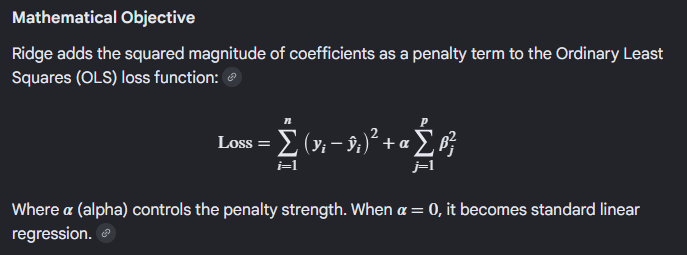

Where (alpha) controls the penalty strength. When alpha = 0, it becomes standard linear regression.**Real-World Example** Imagine you are predicting house prices. Your dataset includes both Square_Footage and Number_of_Rooms. These two features are highly correlated. Standard linear regression might give unstable, massive coefficients to both. Ridge steps in and shrinks both coefficients proportionally, ensuring neither wildly dominates the model.

***L_1 Regularization (Lasso penalty)***: **Shrinks coefficients all the way to zero.** It completely removes unimportant features, performing automatic feature selection

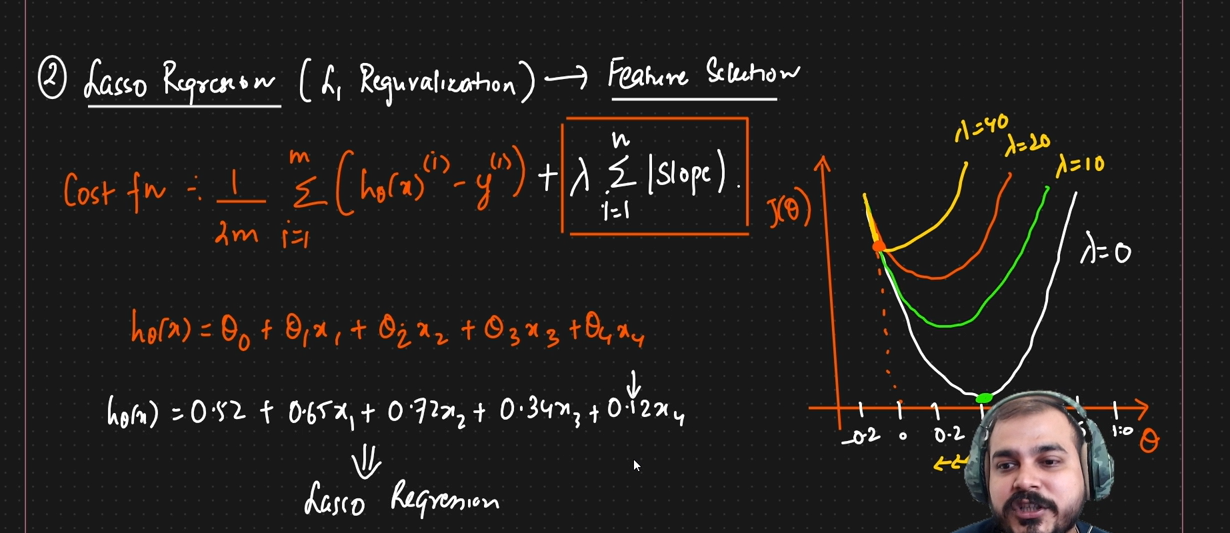

Why We Use It :


To achieve feature selection in datasets with too many variables.To create sparse models (models where most coefficients are exactly zero), making them easier to interpret.



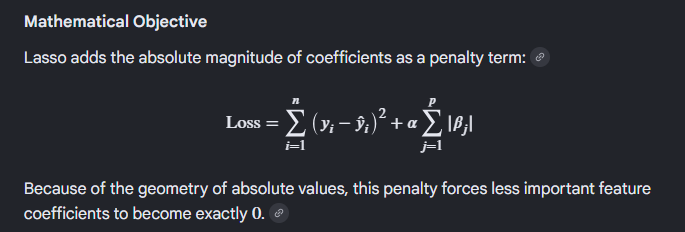


**Real-World Example **:Imagine predicting patient health risks using \(10,000\) different genetic markers. Most markers are useless noise. Lasso regression will drive the coefficients of the thousands of irrelevant markers to exactly \(0\). You are left with a short, clean list of the top \(10\) or \(20\) genetic markers that actually matter.

Overfitting
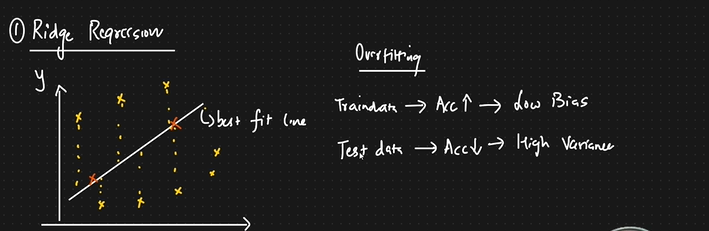


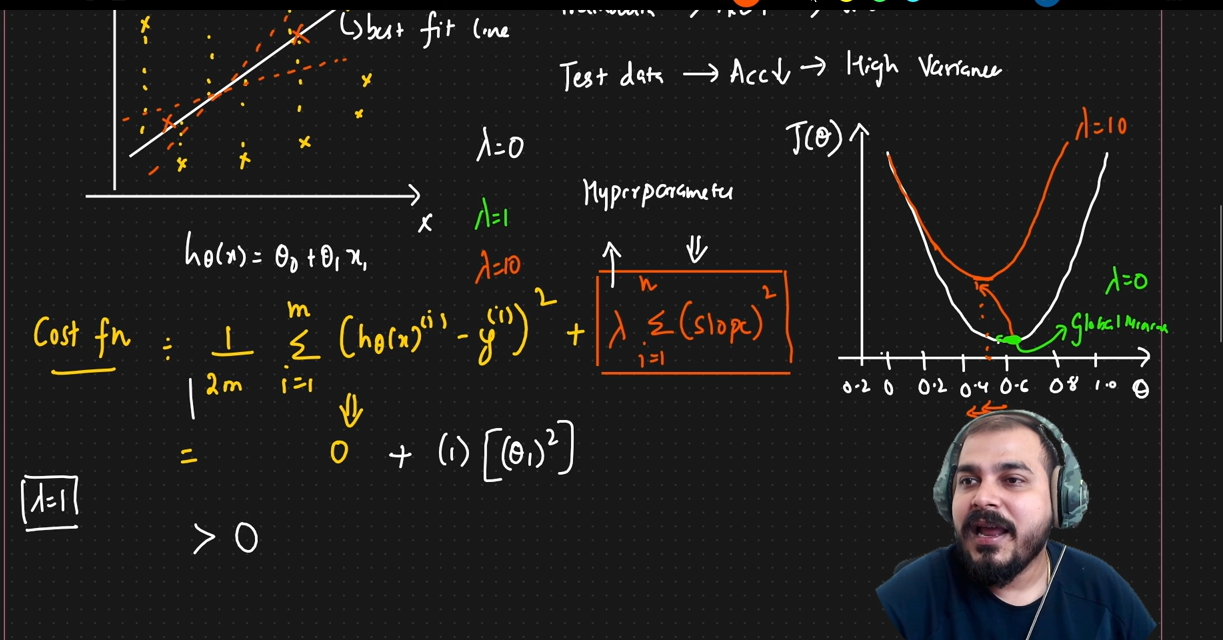


***Type of Cross Validation***

---
Cross-validation is a statistical method used to estimate the performance of machine learning models by splitting data into separate training and testing sets multiple times. It ensures that a model generalizes well to unseen data and helps prevent overfitting.

1. Holdout Method

The Holdout Method is the simplest type of cross-validation where the dataset is split into two parts: a training set and a testing set.

**How it works:** You train the model on the first portion and evaluate it on the remaining portion.Example: You have a dataset of 100 house prices. You randomly select 80 houses to train your model (80% training set) and use the remaining 20 houses to test how accurately it predicts prices (20% test set).


2. K-Fold Cross-Validation


K-Fold Cross-Validation splits the entire dataset into \(K\) equal-sized sub-samples (called folds) to ensure every data point gets a chance to be in the test set.

**How it works:** The model trains \(K\) times. In each iteration, \(K-1\) folds are used for training, and the remaining 1 fold is used for testing. The final performance score is the average of all \(K\) runs.

Example: You have 100 patient records and choose \(K = 5\) (5-Fold). The data is split into 5 folds of 20 patients each.Iteration 1: Train on Folds 2, 3, 4, 5. Test on Fold 1.Iteration 2: Train on Folds 1, 3, 4, 5. Test on Fold 2.(Repeat until all 5 folds have served as the test set).


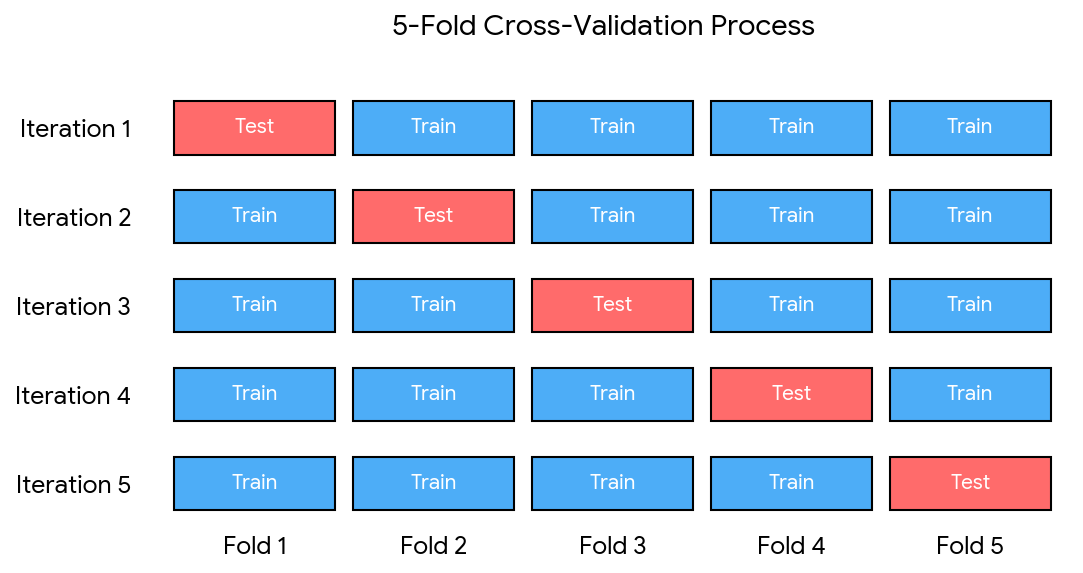


3. Stratified K-Fold Cross-Validation


Stratified K-Fold is a variation of K-Fold designed specifically for imbalanced datasets to maintain the target class proportions across all splits.

How it works: It ensures that the percentage of target classes (e.g., "Yes" vs "No") is identical in every single fold to how it appears in the entire dataset.

Example: You have a dataset of 100 bank transactions where 10 are fraudulent (10%) and 90 are legitimate (90%). In a 5-fold split, Stratified K-Fold forces every single fold to contain exactly 2 fraudulent and 18 legitimate transactions.

4. Leave-One-Out Cross-Validation (LOOCV)


Leave-One-Out Cross-Validation is an extreme case of K-Fold where \(K\) equals the total number of data points (\(N\)) in your dataset.

How it works: The model trains on \(N-1\) samples and tests on exactly one single data point. This repeats \(N\) times until every single data point has been used as a test subject.

Example: You have a rare disease dataset containing only 20 patient samples. The model trains on 19 patients and tests its prediction on the 1 remaining patient. This process repeats 20 times, yielding 20 individual accuracy checks.


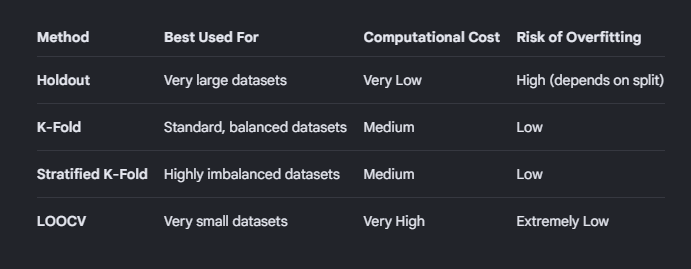


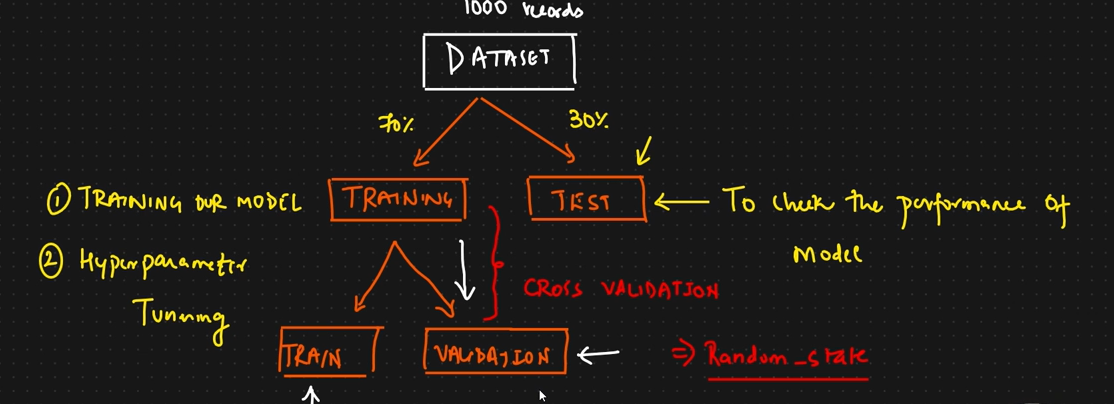

Now we fill practice by the dataset


**Algerian Forest Fires Dataset**

---
The dataset includes 244 instances that regroup a data of two regions of Algeria, namely the Bejaia region located in the northeast of Algeria and the Sidi Bel-abbes region located in the northwest of Algeria.

122 instances for each region.

The period from June 2012 to September 2012.
The dataset includes 11 attributes and 1 output attribute (class)
The 244 instances have been classified into fire (138 classes) and not fire (106 classes) classes.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [ ]:
df=pd.read_csv("/content/sample_data/Algerian_forest_fires_dataset.csv")
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


### Explanation of Column Abbreviations:
*   **RH**: Relative Humidity
*   **Ws**: Wind Speed
*   **FFMC**: Fine Fuel Moisture Code
*   **DMC**: Duff Moisture Code
*   **DC**: Drought Code
*   **ISI**: Initial Spread Index
*   **BUI**: Buildup Index
*   **FWI**: Fire Weather Index

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.1+ KB


***Data Clening***

In [ ]:
df.isnull().sum()

,0
day,1
month,2
year,2
Temperature,2
RH,2
Ws,2
Rain,2
FFMC,2
DMC,2
DC,2


In [ ]:
#To find any columns as null values
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [ ]:
#The dataset is convert into two sets base on the region and add a new columns with regin
df.loc[:123,"Region"]=0
df.loc[123:,"Region"]=1
df.head()


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          246 non-null    object 
 1   month        245 non-null    object 
 2   year         245 non-null    object 
 3   Temperature  245 non-null    object 
 4    RH          245 non-null    object 
 5    Ws          245 non-null    object 
 6   Rain         245 non-null    object 
 7   FFMC         245 non-null    object 
 8   DMC          245 non-null    object 
 9   DC           245 non-null    object 
 10  ISI          245 non-null    object 
 11  BUI          245 non-null    object 
 12  FWI          245 non-null    object 
 13  Classes      244 non-null    object 
 14  Region       247 non-null    float64
dtypes: float64(1), object(14)
memory usage: 29.1+ KB


In [ ]:
df[['Region']]=df[["Region"]].astype(int)
#Convet flota to integer

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
 14  Region       247 non-null    int64 
dtypes: int64(1), object(14)
memory usage: 29.1+ KB


In [ ]:
df.isnull().sum()

,0
day,1
month,2
year,2
Temperature,2
RH,2
Ws,2
Rain,2
FFMC,2
DMC,2
DC,2


In [ ]:
##Removing Null values
df=df.dropna().reset_index(drop=True)
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [ ]:
df.isnull().sum()

,0
day,0
month,0
year,0
Temperature,0
RH,0
Ws,0
Rain,0
FFMC,0
DMC,0
DC,0


In [ ]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1


In [ ]:
df=df.drop(index=122).reset_index(drop=True)

In [ ]:
df.loc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,1,6,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1


In [ ]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='object')

In [ ]:
#Fix Space in columns name
df.columns=df.columns.str.strip()
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

**Change the requred columns as integer Data type and float are folat Datatype**

In [ ]:
numeric_cols = ['Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
for col in ['Temperature', 'RH', 'Ws']:
    df[col] = df[col].astype(str).str.replace(r'[^\d.]', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    object 
 1   month        243 non-null    object 
 2   year         243 non-null    object 
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(4), object(4)
memory usage: 28.6+ KB


In [ ]:
df.describe()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [ ]:
#let save the cleaned Dataset
df.to_csv("Algerian_forest_fires_cleaned_dataset.csv",index=False)

In [ ]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


***Now we will do EDA(Explority Data Analysis)***

In [ ]:
df_copy=df.drop(['day','month','year'],axis=1)
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [ ]:
df_copy['Classes'].value_counts()

,count
Classes,
fire,131
not fire,101
fire,4
fire,2
not fire,2
not fire,1
not fire,1
not fire,1


In [ ]:
#Encoding of the categorical in classes
# Ensure the column is string type and strip any leading/trailing whitespace
df_copy['Classes'] = df_copy['Classes'].astype(str).str.strip()
# Now perform the encoding
df_copy['Classes']=np.where(df_copy['Classes']=='not fire',0,1)
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [ ]:
df_copy['Classes'].value_counts()

,count
Classes,
1,137
0,106


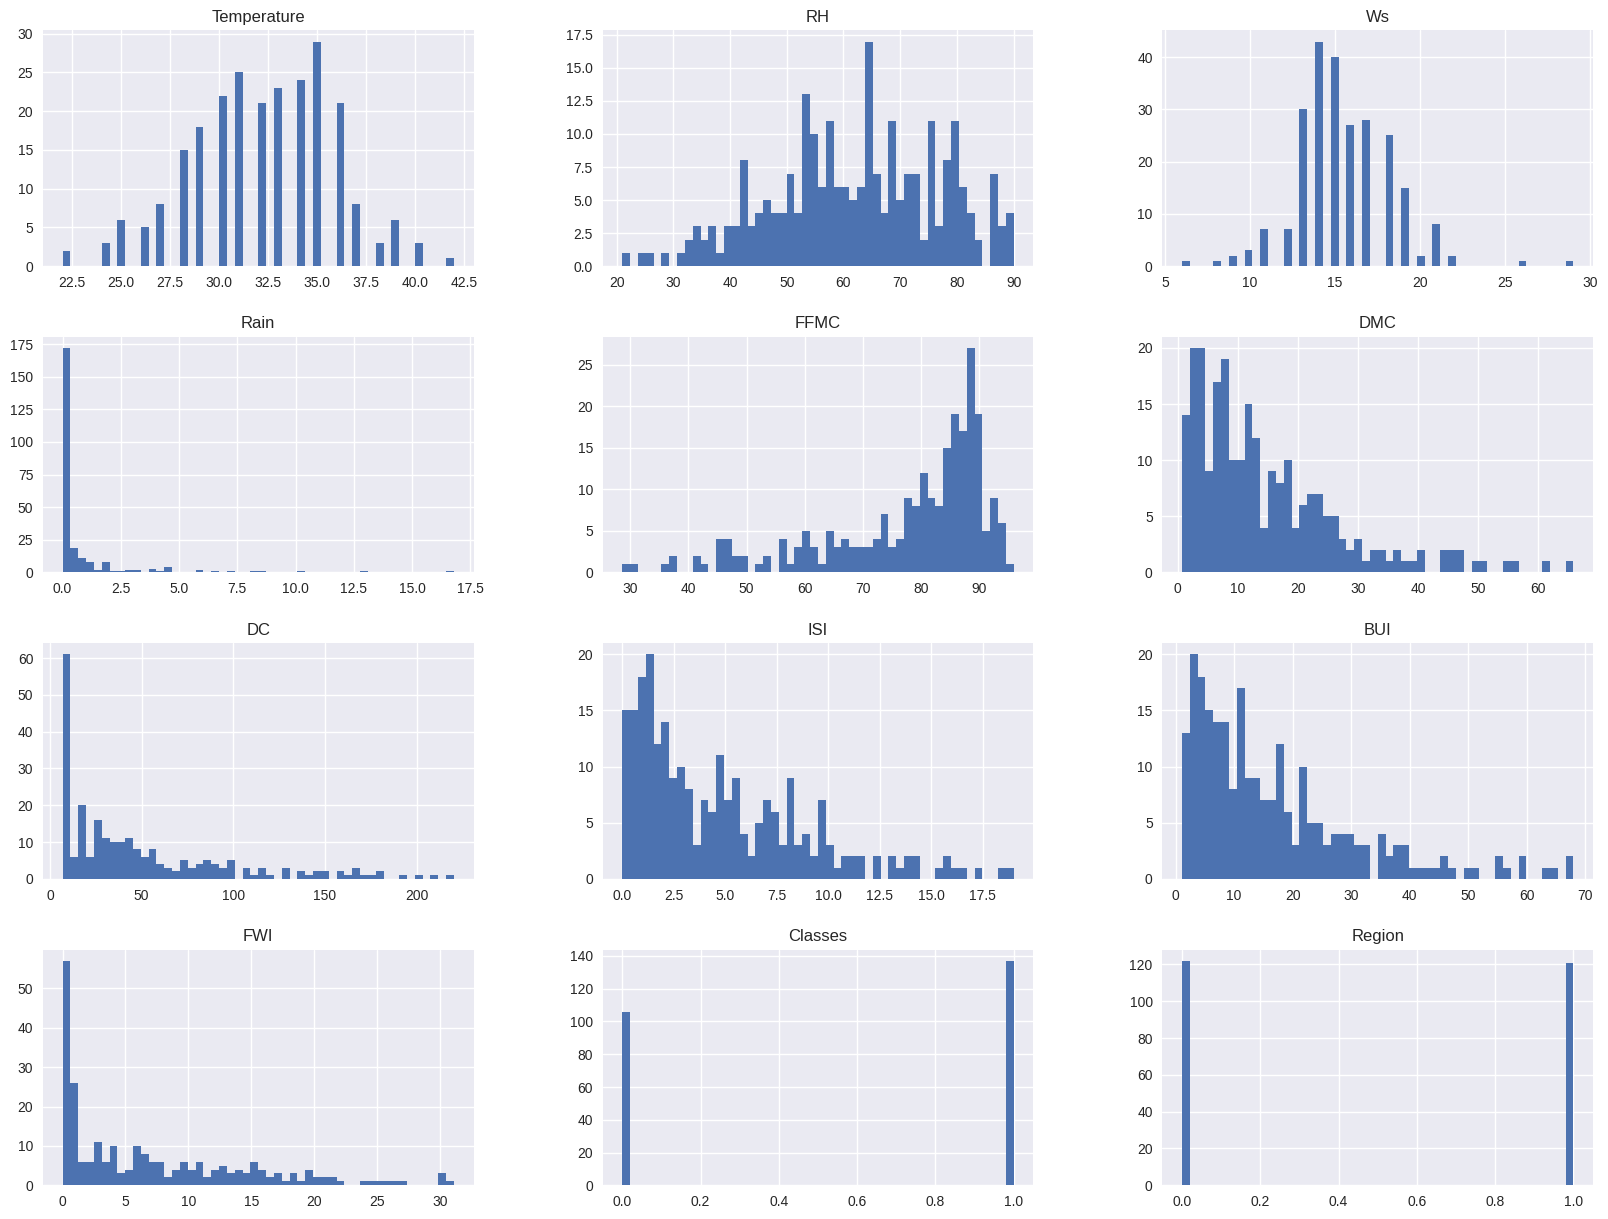

In [ ]:
##Plot density plot for all feature

plt.style.use("seaborn-v0_8")
df_copy.hist(bins=50,figsize=(20,15))
plt.show()

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  243 non-null    int64  
 1   RH           243 non-null    int64  
 2   Ws           243 non-null    int64  
 3   Rain         243 non-null    float64
 4   FFMC         243 non-null    float64
 5   DMC          243 non-null    float64
 6   DC           243 non-null    float64
 7   ISI          243 non-null    float64
 8   BUI          243 non-null    float64
 9   FWI          243 non-null    float64
 10  Classes      243 non-null    int64  
 11  Region       243 non-null    int64  
dtypes: float64(7), int64(5)
memory usage: 22.9 KB


In [ ]:
#Percetagefor pie chart
percentage=df_copy['Classes'].value_counts(normalize=True)*100

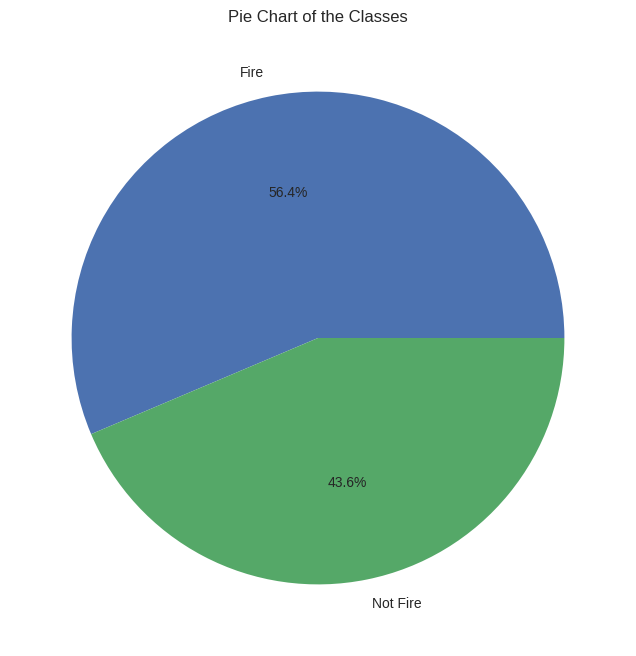

In [ ]:
#Plotting pie chart

classlabls=['Fire','Not Fire']
plt.figure(figsize=(8,8))
plt.pie(percentage,labels=classlabls,autopct='%1.1f%%')
plt.title("Pie Chart of the Classes")
plt.show()

In [ ]:
#Correlation
df_copy.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


<Axes: >

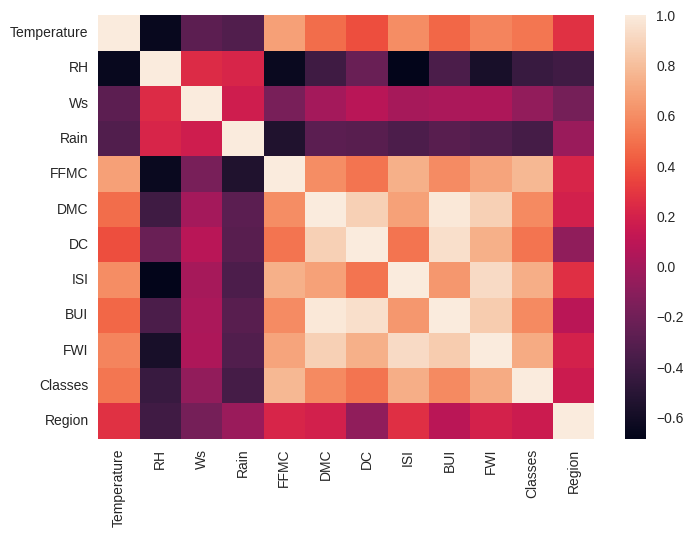

In [ ]:
sns.heatmap(df_copy.corr())

<Axes: ylabel='FWI'>

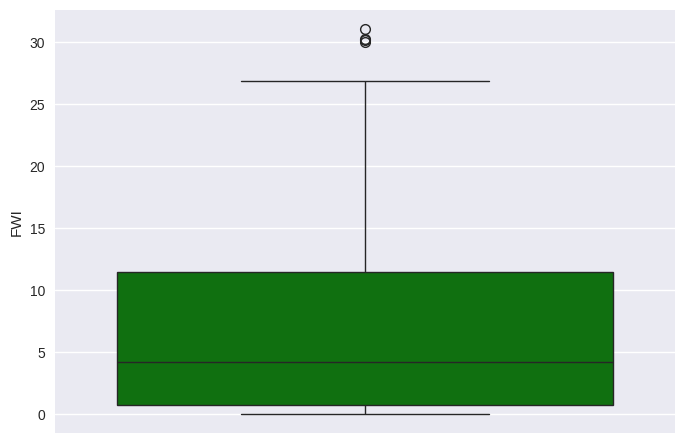

In [ ]:
#Impelementation Box Plots
sns.boxplot(df['FWI'],color='g')

In [ ]:
df['Classes']=np.where(df['Classes'].str.contains('not fire'),"not fire",'fire')

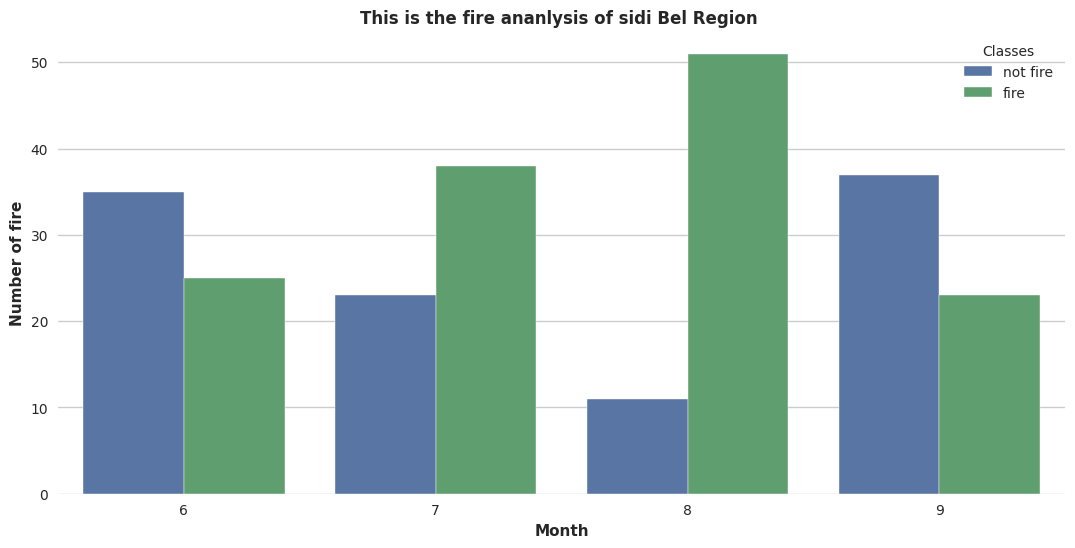

In [ ]:
#Monthly fIRE Analysis
dftemp=df.loc[df['Region']==1]
plt.figure(figsize=(13,6))
sns.set_style("whitegrid")
sns.countplot(x='month',hue='Classes',data=df)
plt.xlabel('Month',weight="bold")
plt.ylabel("Number of fire",weight='bold')
plt.title("This is the fire ananlysis of sidi Bel Region ",weight='bold')
plt.show()

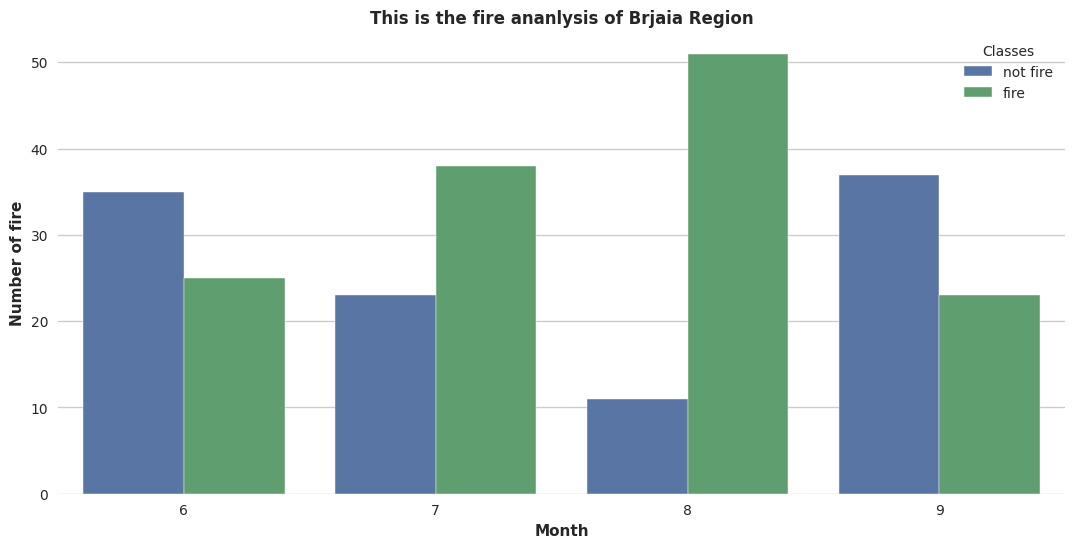

In [ ]:
#Monthly fIRE Analysis
dftemp=df.loc[df['Region']==0]
plt.figure(figsize=(13,6))
sns.set_style("whitegrid")
sns.countplot(x='month',hue='Classes',data=df)
plt.xlabel('Month',weight="bold")
plt.ylabel("Number of fire",weight='bold')
plt.title("This is the fire ananlysis of Brjaia Region",weight='bold')
plt.show()

**3. ElasticNet Regression**
Why We Use It

   1.To combine the benefits of both Ridge and Lasso.
   
   2.To fix Lasso's limitation: when multiple features are correlated, Lasso blindly picks one and ignores the rest. ElasticNet groups them together.

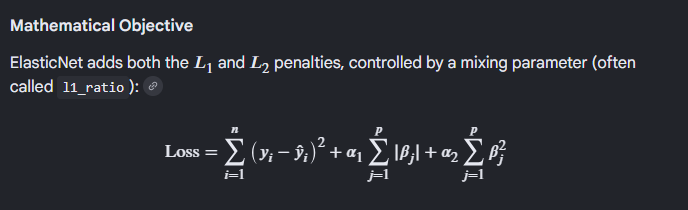


***Real-World Example***


Imagine predicting stock prices using hundreds of financial metrics. You have groups of highly correlated features (like Quarterly_Revenue, Annual_Revenue, and Gross_Profit).

 1.***Lasso m***ight randomly pick Gross_Profit and delete the other two, losing predictive power.

 2.***Ridge will kee***p all three, even if you want a simpler model.

3. t will**ElasticNe** select the entire group of revenue metrics together, shrink them responsibly, and still eliminate completely unrelated junk features (like Employee_Count).